# 01. 데이터 수집 + EDA

**Phase 1 — Step 1**

## 이 노트북의 역할

1. **yfinance**로 SPY, QQQ 일별 OHLCV 다운로드 (2009-01-01 ~ 2026-03-31)
2. 결측·이상치 점검 (보수적 기준)
3. 일별 log-return 분포 (히스토그램 + QQ-plot)
4. **ACF/PACF lag 1~30** — 사용자 가설 "수익률의 자기상관이 극단적으로 약함" 정량 검증
5. 분석 기간(2016-01-01~2025-12-31) 집중 통계

## 왜 다운로드 기간과 분석 기간이 다른가

- **다운로드**: 2009-01-01 ~ 2026-03-31 (약 17년, 워밍업 + 최신 데이터 확보)
- **분석**: 2016-01-01 ~ 2025-12-31 (10년, 실제 모델 학습·평가 대상)

Phase 1에서 seq_len=126일(약 6개월) 또는 24개월 lookback을 사용하므로, 분석 시작일(2016-01-01) 이전의 데이터가 lookback 윈도우 채움용으로 필요합니다. 2009년부터 받아두면 어떤 lookback 크기로 실험해도 윈도우가 분석 시작일을 모두 채울 수 있습니다.

## Adj Close를 쓰는 이유

`Adj Close`(Adjusted Close)는 배당·주식분할을 반영한 조정 종가입니다. 수익률 계산의 표준이며, `Close`만 쓰면 배당락·분할 시점에 비현실적인 음의 수익률이 발생합니다.

## 누수 위험 평가

이 노트북은 **EDA만** 수행합니다. 모델 학습이 없으므로 직접적 누수 위험은 없으나, 다음 두 가지를 준수합니다.
1. 분석 기간 외(워밍업) 데이터의 통계를 분석 기간 통계와 섞어서 보고하지 않음
2. 이상치 임계(±Nσ)는 **분석 기간 내**에서만 계산 (미래 데이터로 과거 기준을 세우지 않음)

## §1. 환경 설정 로드

`00_setup_and_utils.ipynb`를 `%run`으로 실행하면 한글 폰트·시드·경로 상수·공통 import가 모두 현재 커널에 들어옵니다.

In [14]:
%run ./00_setup_and_utils.ipynb

[OK] scripts.setup import 완료 — BASE_DIR = /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/시계열_Test/Phase1_LSTM
[OK] 한글 폰트 설정 완료: AppleGothic
[OK] 시드 고정 완료: SEED=42
[정보] PyTorch 버전: 2.11.0, CUDA 가용: False
[OK] 경로 상수 확인
  BASE_DIR      = /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/시계열_Test/Phase1_LSTM
  RAW_DATA_DIR  = /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/시계열_Test/Phase1_LSTM/results/raw_data
  SETTING_A_DIR = /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/시계열_Test/Phase1_LSTM/results/setting_A
  SETTING_B_DIR = /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/시계열_Test/Phase1_LSTM/results/setting_B
[OK] 공통 import + 표시 옵션 적용 완료
  pandas 2.3.3, numpy 2.4.4
  Phase 1 — LSTM 단독 베이스라인 / 환경 설정 완료
  한글 폰트  : AppleGothic
  시드       : 42
  결과 경로  : /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/시계열_Test/Phase1_LSTM/results
  진실원     : scripts/se

## §2. yfinance 다운로드

### 2.1 yfinance 가용성 확인

yfinance는 Yahoo Finance의 비공식 API입니다. 버전에 따라 반환 형식(MultiIndex 컬럼 여부)이 다르므로 코드에서 방어적으로 처리합니다.

### 2.2 다운로드 방침

- **티커**: SPY(S&P 500 ETF), QQQ(나스닥 100 ETF)
- **기간**: 2009-01-01 ~ 2026-03-31
- **간격**: `1d` (일별)
- **auto_adjust=False**: OHLC와 Adj Close를 **별도 컬럼으로 모두** 받기 위함. `True`면 Close가 이미 조정되어 구분 불가.
- **저장**: `results/raw_data/{ticker}.csv`

### 2.3 재현성 함정

yfinance의 과거 데이터는 가끔 이전 버전과 미세하게 다를 수 있습니다(Yahoo 내부 재조정). 한 번 다운받고 CSV로 저장한 뒤에는 CSV에서만 읽어 사용해 재현성을 확보합니다. CSV가 이미 있으면 다시 받지 않습니다.

In [15]:
# yfinance import. 미설치 시 안내 메시지 출력.
try:
    import yfinance as yf
    print(f'[OK] yfinance 버전: {yf.__version__}')
except ImportError:
    print('[경고] yfinance가 설치되어 있지 않습니다.')
    print('       pip install yfinance')
    raise

[OK] yfinance 버전: 1.2.1


In [16]:
# 다운로드 파라미터
TICKERS = ['SPY', 'QQQ']
DOWNLOAD_START = '2009-01-01'
DOWNLOAD_END = '2026-03-31'


def download_one_ticker(ticker: str, start: str, end: str, save_dir: Path) -> pd.DataFrame:
    """단일 티커를 yfinance로 다운로드하고 CSV로 저장한다.

    이미 동일 경로에 CSV가 있으면 재다운로드하지 않고 읽어 반환한다.
    재현성 확보를 위한 캐싱 정책이다.

    Parameters
    ----------
    ticker : str
        Yahoo Finance 티커 (예: 'SPY', 'QQQ').
    start, end : str
        다운로드 기간 (YYYY-MM-DD).
    save_dir : Path
        CSV 저장 디렉토리.

    Returns
    -------
    pd.DataFrame
        인덱스가 date(DatetimeIndex)인 OHLCV + Adj Close 데이터프레임.
    """
    csv_path = save_dir / f'{ticker}.csv'

    # 캐시가 있으면 CSV에서 읽음 (재현성)
    if csv_path.exists():
        print(f'  [캐시] {ticker}: {csv_path.name} 이미 존재 → CSV에서 로드')
        df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
        return df

    # yfinance 다운로드 (단일 티커, auto_adjust=False)
    print(f'  [다운로드] {ticker}: {start} ~ {end}')
    df = yf.download(
        ticker,
        start=start,
        end=end,
        interval='1d',
        auto_adjust=False,
        progress=False,
    )

    # yfinance 버전에 따라 MultiIndex 컬럼이 반환될 수 있음 → 평탄화
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    if df.empty:
        raise RuntimeError(f'{ticker} 다운로드 결과가 비어 있습니다. 인터넷 연결/티커명 확인.')

    # 인덱스명 통일
    df.index.name = 'date'
    df.to_csv(csv_path)
    print(f'  [저장] {csv_path}  ({len(df)} 행)')
    return df


# 실제 다운로드 실행
raw_dict: Dict[str, pd.DataFrame] = {}
for tic in TICKERS:
    raw_dict[tic] = download_one_ticker(tic, DOWNLOAD_START, DOWNLOAD_END, RAW_DATA_DIR)

print()
for tic, df in raw_dict.items():
    print(f'[{tic}] 행수={len(df)}, 기간={df.index.min().date()} ~ {df.index.max().date()}')

  [캐시] SPY: SPY.csv 이미 존재 → CSV에서 로드
  [캐시] QQQ: QQQ.csv 이미 존재 → CSV에서 로드

[SPY] 행수=4336, 기간=2009-01-02 ~ 2026-03-30
[QQQ] 행수=4336, 기간=2009-01-02 ~ 2026-03-30


In [17]:
# 다운로드된 컬럼·자료형 확인 (SPY 기준, QQQ도 동일 포맷)
print('[SPY] 컬럼 구성:')
print(raw_dict['SPY'].dtypes)
print()
print('[SPY] 처음 3행:')
raw_dict['SPY'].head(3)

[SPY] 컬럼 구성:
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

[SPY] 처음 3행:


,Adj Close,Close,High,Low,Open,Volume
date,,,,,,
2009-01-02,67.981262,92.959999,93.440002,89.849998,90.440002,227566300
2009-01-05,67.900810,92.849998,93.660004,91.889999,92.629997,240349700
2009-01-06,68.354225,93.470001,94.449997,92.680000,93.639999,328260900


## §3. 결측·이상치 점검

### 점검 항목

1. **결측치**: 컬럼별 NaN 개수
2. **거래일 연속성**: NYSE 개장일 기준 중간에 비는 날짜가 있는지
3. **Adj Close 양수 여부**: 음수·0은 로그 수익률 계산 불가
4. **극단 이상치**: |log_return| > **5σ**인 날의 개수와 날짜

### 이상치 임계를 ±5σ로 잡는 이유 (보수적)

CLAUDE.md 지침: "데이터를 drop하거나 변형하는 기준은 최대한 보수적으로 잡을 것."

- ±3σ: 정상 분포 기준 ~0.27% 발생 → 2,520 영업일 기준 ~7일 → 너무 많이 걸림
- **±5σ**: 정상 분포 기준 ~6e-5% → 16년치에도 2~3일 이하 → 진짜 이상치만 포착
- **실제 수익률은 fat-tail**이므로 정상 분포 계산보다 훨씬 많이 걸릴 수 있음. 걸린 날은 **리포트만 하고 제거는 하지 않음** (COVID 2020-03-16, 금융위기 2009 등은 실제 사건)

In [18]:
def data_quality_report(ticker: str, df: pd.DataFrame) -> pd.DataFrame:
    """결측·음수/0·거래일 연속성을 점검한다.

    Returns
    -------
    pd.DataFrame
        점검 항목별 한 줄 요약.
    """
    # 1. 결측치
    n_missing = df.isna().sum().sum()

    # 2. Adj Close 양수 여부
    n_nonpositive = int((df['Adj Close'] <= 0).sum())

    # 3. 거래일 연속성 (index 차이 > 7일이면 이상)
    idx_diff = df.index.to_series().diff().dt.days
    gap_days = int((idx_diff > 7).sum())  # 일주일 이상 공백 (거래소 장기 휴장 외엔 없음)

    # 4. 중복 인덱스
    n_dup = int(df.index.duplicated().sum())

    return pd.DataFrame({
        '항목': ['결측치 총합', 'Adj Close ≤ 0 일수', '7일 이상 공백 구간', '중복 날짜'],
        '값': [n_missing, n_nonpositive, gap_days, n_dup],
    }).assign(ticker=ticker)


# 각 티커별 품질 리포트
quality_reports = pd.concat([data_quality_report(t, df) for t, df in raw_dict.items()])
quality_reports.pivot(index='항목', columns='ticker', values='값')

ticker,QQQ,SPY
항목,,
7일 이상 공백 구간,0,0
Adj Close ≤ 0 일수,0,0
결측치 총합,0,0
중복 날짜,0,0


In [19]:
# log-return 계산 (Adj Close 기준) — 원본 DataFrame에 컬럼 추가
for tic, df in raw_dict.items():
    df['log_return'] = np.log(df['Adj Close']).diff()

# ±5σ 이상치 검출 — **분석 기간 내에서만** 기준 통계 계산 (누수 방지)
ANALYSIS_START = '2016-01-01'
ANALYSIS_END = '2025-12-31'


def detect_extreme_outliers(df: pd.DataFrame, sigma_thresh: float = 5.0,
                            start: str = ANALYSIS_START, end: str = ANALYSIS_END) -> pd.DataFrame:
    """|log_return| > k*σ 인 날짜를 반환. σ는 분석 기간 내에서만 계산한다.

    누수 방지: 분석 시작 전(2016 이전) 데이터로 이상치 기준을 잡으면 안 된다.
    반대로 분석 기간 전체 데이터로 σ를 잡는 것은 허용되지만, 엄격한 Walk-Forward에서는
    각 fold별로 σ 재계산이 필요할 수 있다. 여기서는 EDA 목적이므로 분석 기간 전체를 쓴다.
    """
    sub = df.loc[start:end].copy()
    sigma = sub['log_return'].std()
    sub['abs_return'] = sub['log_return'].abs()
    mask = sub['abs_return'] > sigma_thresh * sigma
    return sub.loc[mask, ['Adj Close', 'log_return']].assign(sigma_used=sigma)


# 각 티커별 극단 이상치 날짜 출력
for tic, df in raw_dict.items():
    outliers = detect_extreme_outliers(df)
    print(f'[{tic}] |log_return| > 5σ 날짜 개수: {len(outliers)}')
    if not outliers.empty:
        print(outliers.head(20))
    print()

[SPY] |log_return| > 5σ 날짜 개수: 9
            Adj Close  log_return  sigma_used
date                                         
2020-03-09 250.610001   -0.081312    0.011370
2020-03-12 226.739700   -0.100569    0.011370
2020-03-13 246.122833    0.082028    0.011370
2020-03-16 219.191162   -0.115886    0.011370
2020-03-24 223.513535    0.086731    0.011370
2020-04-06 243.470245    0.065007    0.011370
2020-06-11 276.333130   -0.059377    0.011370
2025-04-04 499.553345   -0.060327    0.011370
2025-04-09 542.402161    0.099863    0.011370

[QQQ] |log_return| > 5σ 날짜 개수: 8
            Adj Close  log_return  sigma_used
date                                         
2020-03-09 186.547150   -0.071995    0.014101
2020-03-12 170.886673   -0.096171    0.014101
2020-03-13 185.361755    0.081309    0.014101
2020-03-16 163.157669   -0.127592    0.014101
2020-03-17 175.531845    0.073103    0.014101
2020-03-24 177.373871    0.074586    0.014101
2022-11-10 276.730042    0.071193    0.014101
2025-04-09 46

## §4. log-return 분포

### 확인 사항

1. **중앙 경향**: 일별 log-return은 0에 가까워야 함 (연 ~10% ÷ 252일 ≈ 0.04%)
2. **분산**: SPY보다 QQQ가 변동성이 크다면 이론과 일치 (기술주 집중)
3. **꼬리**: QQ-plot에서 S자 곡선 → fat-tail (정규분포 가정 위반)
4. **왜도·첨도**: 금융 수익률은 보통 음의 왜도(왼쪽 꼬리) + 높은 첨도(leptokurtic)

### 정규화 필요성 평가

log-return 자체가 이미 수준 차이를 제거한 정상화된 시계열입니다. 추가 StandardScaler 필요 여부는 시각화 후 결정합니다 — 분포가 매우 뾰족하면 학습 안정성을 위해 적용 가능.

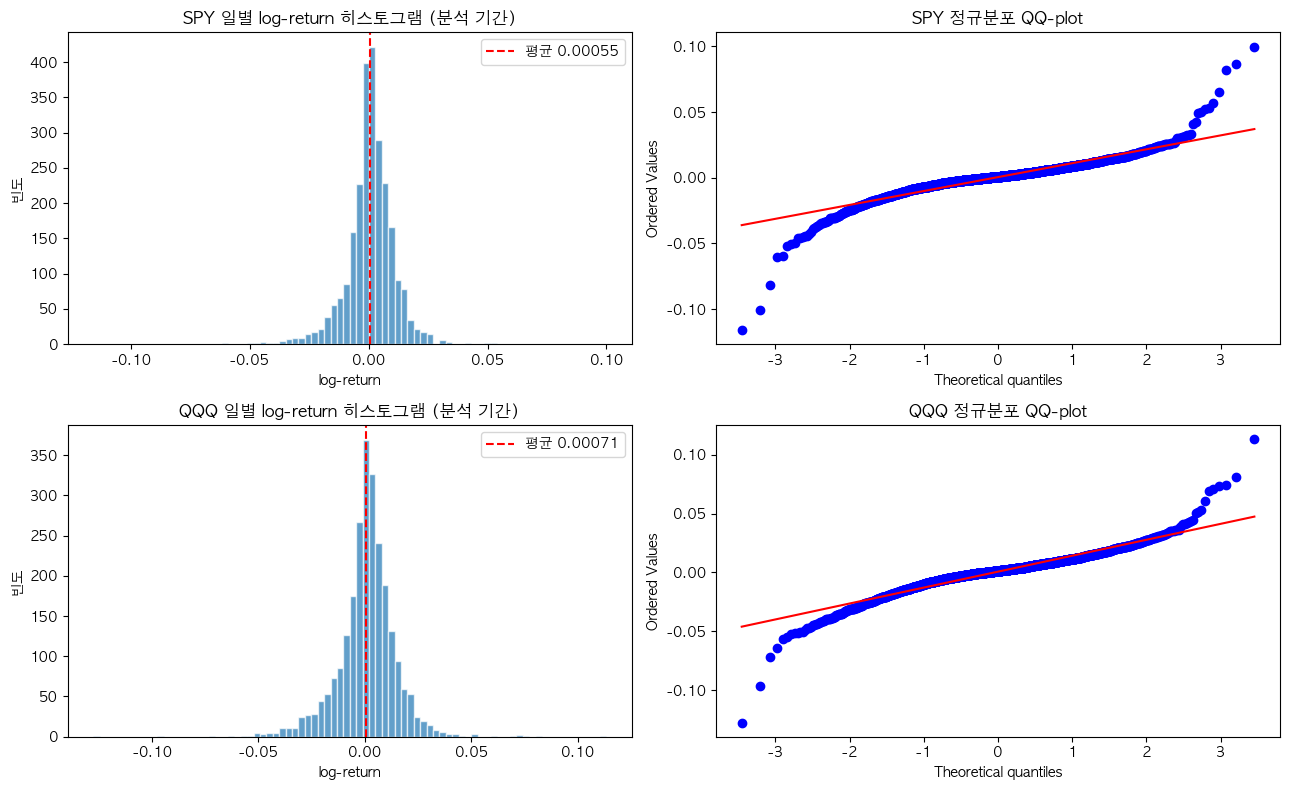

In [20]:
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for row, tic in enumerate(TICKERS):
    lr = raw_dict[tic].loc[ANALYSIS_START:ANALYSIS_END, 'log_return'].dropna()

    # 히스토그램 (왼쪽)
    ax_hist = axes[row, 0]
    ax_hist.hist(lr, bins=80, edgecolor='white', alpha=0.7)
    ax_hist.axvline(lr.mean(), color='red', linestyle='--', label=f'평균 {lr.mean():.5f}')
    ax_hist.set_title(f'{tic} 일별 log-return 히스토그램 (분석 기간)')
    ax_hist.set_xlabel('log-return')
    ax_hist.set_ylabel('빈도')
    ax_hist.legend()

    # QQ-plot (오른쪽)
    ax_qq = axes[row, 1]
    stats.probplot(lr, dist='norm', plot=ax_qq)
    ax_qq.set_title(f'{tic} 정규분포 QQ-plot')

plt.tight_layout()
plt.show()

In [21]:
# 기술 통계 요약 (분석 기간 내)
stats_rows = []
for tic in TICKERS:
    lr = raw_dict[tic].loc[ANALYSIS_START:ANALYSIS_END, 'log_return'].dropna()
    stats_rows.append({
        'ticker': tic,
        'n': len(lr),
        '평균': lr.mean(),
        '표준편차': lr.std(),
        '왜도': lr.skew(),
        '첨도(excess)': lr.kurt(),  # pandas는 excess kurtosis (정규분포 0 기준)
        '최소': lr.min(),
        '최대': lr.max(),
    })

pd.DataFrame(stats_rows).set_index('ticker')

,n,평균,표준편차,왜도,첨도(excess),최소,최대
ticker,,,,,,,
SPY,2514,0.000546,0.011370,-0.603652,15.137136,-0.115886,0.099863
QQQ,2514,0.000706,0.014101,-0.403157,7.891148,-0.127592,0.113356


## §5. ACF / PACF — 자기상관 정량 확인 ⭐

### 이 섹션이 Phase 1에서 가장 중요한 이유

사용자 가설: "수익률의 자기상관이 극단적으로 작아 univariate LSTM으로는 성능이 안 나올 것"

이 가설을 **Phase 1 모델 학습 전에 정량적으로 확인**하는 것이 본 섹션의 목적입니다. ACF/PACF에서 모든 lag가 95% 신뢰구간 안에 있다면 "어떤 시계열 모델이라도 미래 수익률을 맞히기는 본질적으로 어렵다"는 사전 증거가 됩니다.

### ACF vs PACF

- **ACF** (Autocorrelation Function): lag k에서 `corr(r_t, r_{t-k})`. 간접 경로(중간 lag 거치는 것) 포함.
- **PACF** (Partial Autocorrelation Function): 중간 lag 효과를 걷어낸 순수 lag k 상관.
- **금융 수익률**: 대부분 ACF/PACF 모든 lag가 0에 가까움 (효율적 시장 가설 정합).
- **제곱/절댓값 수익률**: 변동성 클러스터링 → 강한 양의 자기상관 (GARCH 계열 모델의 근거)

### 95% 신뢰구간

`statsmodels.plot_acf`는 ±1.96/√n 을 95% 신뢰구간으로 표시합니다. 이 구간 밖의 lag는 통계적으로 유의한 자기상관이 있다는 뜻이지만, **통계적 유의 ≠ 경제적 의미**입니다. lag 1 ACF가 -0.05여도 t-검정에서 유의할 수 있지만 실제 예측력은 미미합니다.

### 추가: 절댓값·제곱 수익률 ACF

원 수익률 ACF는 작아도 변동성에는 구조가 있을 수 있습니다. Phase 1은 수익률 예측이 목적이므로 참고용으로만 확인합니다.

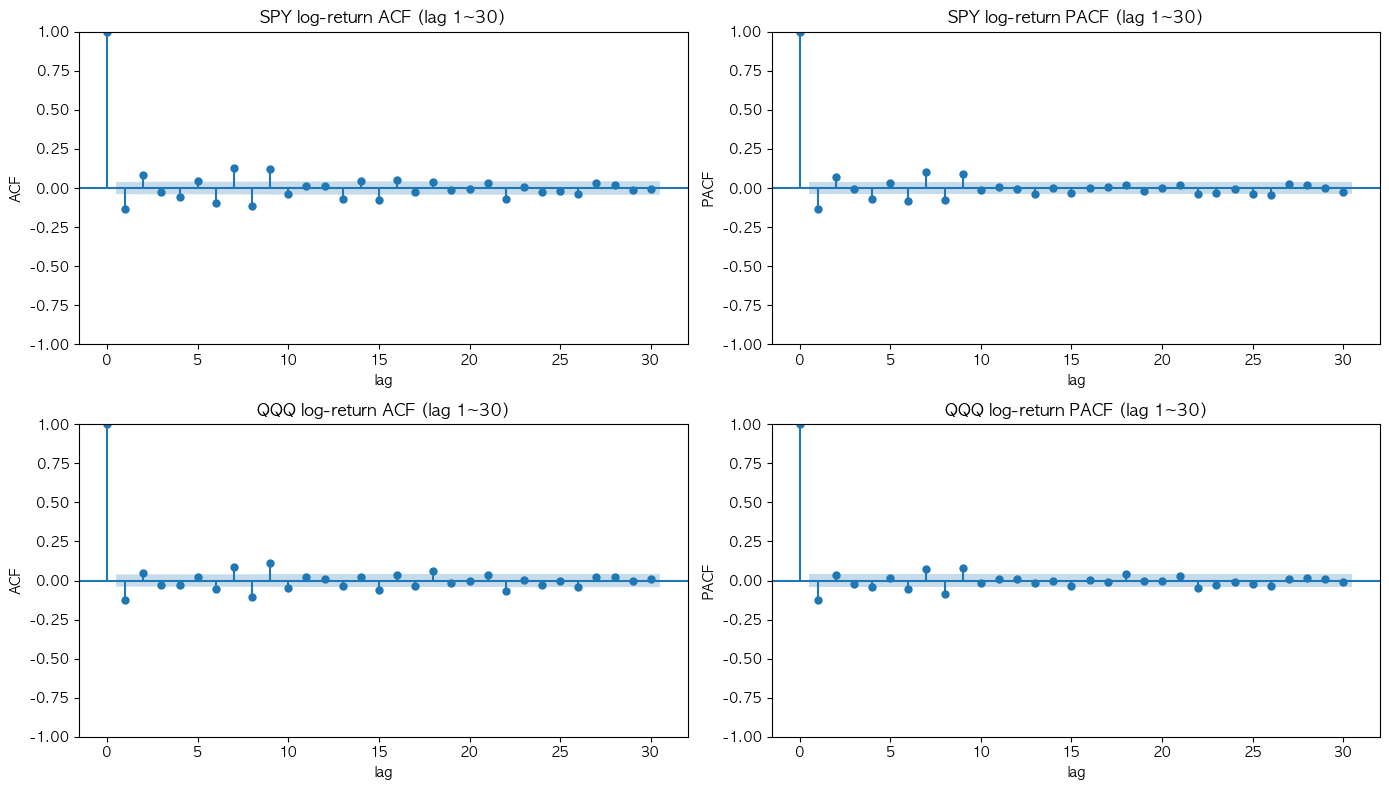

In [22]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

LAG_MAX = 30

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, tic in enumerate(TICKERS):
    lr = raw_dict[tic].loc[ANALYSIS_START:ANALYSIS_END, 'log_return'].dropna()

    # ACF (왼쪽)
    plot_acf(lr, lags=LAG_MAX, ax=axes[row, 0], title=f'{tic} log-return ACF (lag 1~{LAG_MAX})')
    axes[row, 0].set_xlabel('lag')
    axes[row, 0].set_ylabel('ACF')

    # PACF (오른쪽)
    plot_pacf(lr, lags=LAG_MAX, ax=axes[row, 1], title=f'{tic} log-return PACF (lag 1~{LAG_MAX})', method='ywm')
    axes[row, 1].set_xlabel('lag')
    axes[row, 1].set_ylabel('PACF')

plt.tight_layout()
plt.show()

In [23]:
# lag 1~10 ACF 수치 직접 출력 (그래프 외 정량 확인용)
from statsmodels.tsa.stattools import acf

rows = []
for tic in TICKERS:
    lr = raw_dict[tic].loc[ANALYSIS_START:ANALYSIS_END, 'log_return'].dropna()
    acf_values = acf(lr, nlags=10, fft=False)
    n = len(lr)
    ci_95 = 1.96 / np.sqrt(n)
    for lag in range(1, 11):
        rows.append({
            'ticker': tic,
            'lag': lag,
            'ACF': acf_values[lag],
            '95%CI±': ci_95,
            '유의(|ACF| > CI)': abs(acf_values[lag]) > ci_95,
        })

pd.DataFrame(rows)

,ticker,lag,ACF,95%CI±,유의(|ACF| > CI)
0,SPY,1,-0.132869,0.039091,True
1,SPY,2,0.085416,0.039091,True
2,SPY,3,-0.025036,0.039091,False
3,SPY,4,-0.058477,0.039091,True
4,SPY,5,0.041938,0.039091,True
5,SPY,6,-0.097341,0.039091,True
6,SPY,7,0.130379,0.039091,True
7,SPY,8,-0.112260,0.039091,True
8,SPY,9,0.123570,0.039091,True
9,SPY,10,-0.037421,0.039091,False


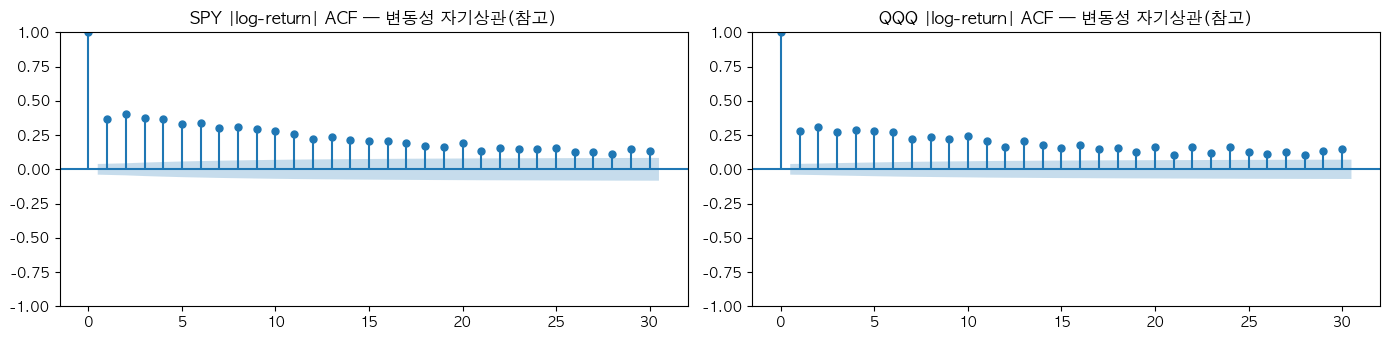

In [24]:
# 참고: 절댓값 수익률 ACF — 변동성 자기상관 (Phase 1에서 직접 사용하진 않음)
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
for col, tic in enumerate(TICKERS):
    lr_abs = raw_dict[tic].loc[ANALYSIS_START:ANALYSIS_END, 'log_return'].dropna().abs()
    plot_acf(lr_abs, lags=LAG_MAX, ax=axes[col], title=f'{tic} |log-return| ACF — 변동성 자기상관(참고)')
plt.tight_layout()
plt.show()

## §6. 분석 기간(2016-01-01 ~ 2025-12-31) 집중 통계

Walk-Forward 구조(IS 231 / purge 21 / emb 21 / OOS 21 / step 21)를 실제로 적용하기 전에, 분석 기간의 기본 숫자를 확인합니다.

- **영업일 수**: 대략 2,520 ± α (연 252 × 10년)
- **월별 샘플 수**: 대략 120 (설정 B에서 핵심)
- **예상 fold 수** (설정 A, 일별):
  - 첫 fold 끝점 = IS(231) + purge(21) + emb(21) + OOS(21) = 294일
  - 이후 step=21일씩 → fold 수 ≈ floor((N - 294) / 21) + 1

In [25]:
# 분석 기간 내 영업일 수 및 월별 샘플 수
analysis_summary = []
for tic in TICKERS:
    df_ana = raw_dict[tic].loc[ANALYSIS_START:ANALYSIS_END]
    n_daily = len(df_ana)
    n_monthly = len(df_ana['Adj Close'].resample('ME').last().dropna())

    # 설정 A fold 수 추정
    IS, PURGE, EMB, OOS, STEP = 231, 21, 21, 21, 21
    fold_size = IS + PURGE + EMB + OOS
    n_folds_A = max(0, (n_daily - fold_size) // STEP + 1)

    # 설정 B fold 수 추정 (월별 비례)
    IS_m, PURGE_m, EMB_m, OOS_m, STEP_m = 11, 1, 1, 1, 1
    fold_size_m = IS_m + PURGE_m + EMB_m + OOS_m
    n_folds_B = max(0, (n_monthly - fold_size_m) // STEP_m + 1)

    analysis_summary.append({
        'ticker': tic,
        '일별 샘플': n_daily,
        '월별 샘플': n_monthly,
        '설정 A fold 수': n_folds_A,
        '설정 B fold 수 (월별 비례 가정)': n_folds_B,
    })

pd.DataFrame(analysis_summary).set_index('ticker')

,일별 샘플,월별 샘플,설정 A fold 수,설정 B fold 수 (월별 비례 가정)
ticker,,,,
SPY,2514,120,106,107
QQQ,2514,120,106,107


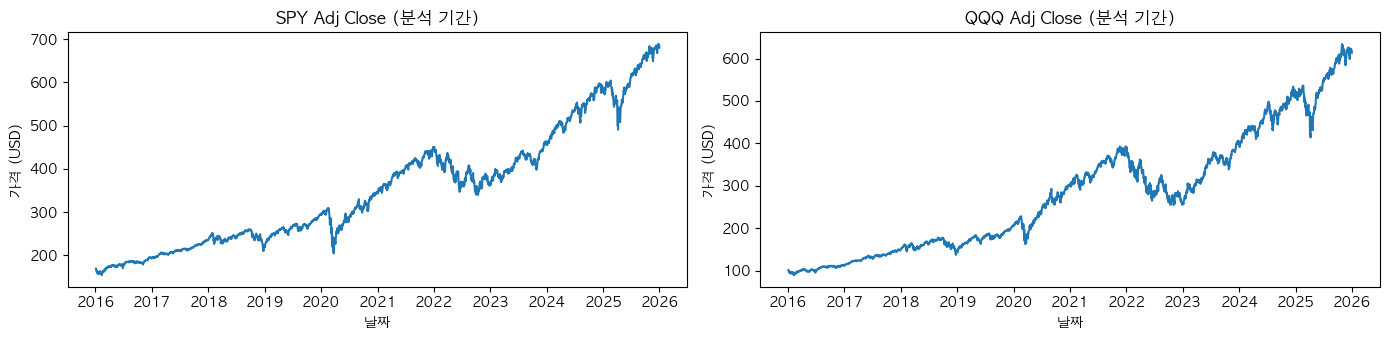

In [26]:
# Adj Close 시계열 시각화 (참고용) — 분석 기간 내
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
for col, tic in enumerate(TICKERS):
    ts = raw_dict[tic].loc[ANALYSIS_START:ANALYSIS_END, 'Adj Close']
    axes[col].plot(ts.index, ts.values)
    axes[col].set_title(f'{tic} Adj Close (분석 기간)')
    axes[col].set_xlabel('날짜')
    axes[col].set_ylabel('가격 (USD)')
plt.tight_layout()
plt.show()

## §7. 결론 · 체크포인트

### 다음 노트북(`02_setting_A_daily21.ipynb`)에 전달할 사실

1. **원본 데이터 경로**: `results/raw_data/{SPY,QQQ}.csv`
2. **분석 기간**: 2016-01-01 ~ 2025-12-31
3. **log-return 분포**: 위 §4 표 참고 (평균·표준편차)
4. **ACF 요약**: 위 §5 표의 lag 1~10 값 (사용자 가설 검증 정량 근거)
5. **결측·이상치**: §3 리포트 참고 — 이상치는 기록만 하고 제거는 하지 않음

### 사용자 확인 요청 사항

- 결측·이상치 처리 방침: **현행(제거 없이 그대로 사용)** 유지 여부
- log-return 분포 형태를 본 뒤 Scaler 적용 여부 결정
- ACF 결과를 근거로 Phase 1 (LSTM) 예측력 기대치 조정

### WORKLOG 업데이트 필요 항목

- Step 1 실행 결과 기록 (다운로드 행 수, 결측·이상치 요약, ACF 수치)